# Biomedical Insurance Cost Predictor (Artificial Neural Network) - Insurance dataset

### 1) Import Libraries

In [41]:
# Import libraries and modules

# ---------- path setup ----------
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT / "Notebooks"))
DATA_DIR = PROJECT_ROOT / "Data/insurance_dataset"

#----- Tools, visualizers -----
from utils import *
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

#----- Preprocessing, Neural Networks -----
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error
)
import tensorflow as tf

#----- Variables -----
RANDOM_STATE = 42



### 2) Load Data

In [46]:
# Load train set
#---------------
data = pd.read_csv(DATA_DIR / "insurance_train_set.csv")
test = pd.read_csv(DATA_DIR / "insurance_test_set.csv")

data.shape, test.shape

((1137, 7), (201, 7))

#### About handling invalid values
Since the dataset at hand is already clean and there are no missing & invalid values, We do not perform this stage in this notebook.

### 3) Define feature columns and target & Split
> Target: charges

#### - Define features & target

In [47]:
"""
Separate features and target for the regression task.

- Target: `charges`
- Features: all columns except `charges`

"""

# -------------------------------------
# charges as the target
# -------------------------------------

# ---------- DATA ---------

# Separate features and labels cols
X_TRAIN = data.drop(columns=['charges']) # Features
y_train = data['charges'] # Labels


# ---------- TEST ---------

# Separate features and labels cols
X_TEST = test.drop(columns=['charges']) # Features
y_test = test['charges'] # Labels


# Display shapes
print("----- DONE -----", end='\n\n')
print(f"Shapes:\n\nX_TRAIN: {X_TRAIN.shape} | y_train: {y_train.shape}")
print(f"X_TEST: {X_TEST.shape} | y_test: {y_test.shape}")


----- DONE -----

Shapes:

X_TRAIN: (1137, 6) | y_train: (1137,)
X_TEST: (201, 6) | y_test: (201,)


#### - Split (train set - val set)

In [48]:
X_train, X_val, y_train, y_val = train_test_split(
    X_TRAIN,
    y_train,
    test_size=0.15,
    random_state=RANDOM_STATE
)

print("---- Done ----")
print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | y_train: {y_train.shape} | y_val: {y_val.shape}")

---- Done ----
X_train: (966, 6) | X_val: (171, 6) | y_train: (966,) | y_val: (171,)


### 4) Core Feature Engineering

#### 1- Feature columns (except target)

In [49]:

# Experiment 1
def smoking_interaction_features(X):
    # Make a copy of X
    x = X.copy()

    # Binarize smoker col - Temporary
    smoker_num = x['smoker'].map({'no': 0, 'yes': 1}) 

    # Build obesity feature that's needed for high_risk feature - temporary
    x['obesity'] = np.where(x['bmi'] >= 30, 1, 0)

    # Build smoker related features
    x['bmi_smoker'] = x['bmi'] * smoker_num
    x['age_smoker'] = x['age'] * smoker_num
    x['high_risk'] = x['obesity'] * smoker_num

    # Drop obesity col
    x.drop(columns=['obesity'], inplace=True)

    return x

# Expriment 2
def bmi_age_related_features(X):
    # Make a copy of X
    x = X.copy()

    # Build bmi/age related features
    x['bmi_age'] = x['age'] * x['bmi']
    x['obesity'] = np.where(x['bmi'] >= 30, 1, 0)
    x['severe_obesity'] = np.where(x['bmi'] >= 35, 1, 0)

    return x

# Experiment 3
def all_eng_featured_combined(X):
    # Make a copy of X
    x = X.copy()

    # Binarize smoker col - Temporary
    smoker_num = x['smoker'].map({'no': 0, 'yes': 1})

    # Build bmi/age related features
    x['bmi_age'] = x['age'] * x['bmi']
    x['obesity'] = np.where(x['bmi'] >= 30, 1, 0)
    x['severe_obesity'] = np.where(x['bmi'] >= 35, 1, 0)

    # Build smoker related features
    x['bmi_smoker'] = x['bmi'] * smoker_num
    x['age_smoker'] = x['age'] * smoker_num
    x['high_risk'] = x['obesity'] * smoker_num

    return x


# Apply smoker related eng
x_smoker_train = smoking_interaction_features(X_train)
x_smoker_val = smoking_interaction_features(X_val)
x_smoker_test = smoking_interaction_features(X_TEST)

# Apply bmi/age related eng
x_bmi_age_train = bmi_age_related_features(X_train)
x_bmi_age_val = bmi_age_related_features(X_val)
x_bmi_age_test = bmi_age_related_features(X_TEST)

# Apply all features eng
x_all_train = all_eng_featured_combined(X_train)
x_all_val = all_eng_featured_combined(X_val)
x_all_test = all_eng_featured_combined(X_TEST)


print("----- Feature Engineering Done -----")


----- Feature Engineering Done -----


In [20]:
# Check basekine
X_train.head(5)

,age,sex,bmi,children,smoker,region
1055,30,female,30.90,3,no,southwest
1035,64,male,26.41,0,no,northeast
78,50,male,37.07,1,no,southeast
192,26,male,23.70,2,no,southwest
536,57,male,42.13,1,yes,southeast


In [21]:
# Check ex1
x_smoker_train.head(5)

,age,sex,bmi,children,smoker,region,bmi_smoker,age_smoker,high_risk
1055,30,female,30.90,3,no,southwest,0.00,0,0
1035,64,male,26.41,0,no,northeast,0.00,0,0
78,50,male,37.07,1,no,southeast,0.00,0,0
192,26,male,23.70,2,no,southwest,0.00,0,0
536,57,male,42.13,1,yes,southeast,42.13,57,1


In [22]:
# Check ex2
x_bmi_age_train.head(5)

,age,sex,bmi,children,smoker,region,bmi_age,obesity,severe_obesity
1055,30,female,30.90,3,no,southwest,927.00,1,0
1035,64,male,26.41,0,no,northeast,1690.24,0,0
78,50,male,37.07,1,no,southeast,1853.50,1,1
192,26,male,23.70,2,no,southwest,616.20,0,0
536,57,male,42.13,1,yes,southeast,2401.41,1,1


In [23]:
# Check ex3
x_all_train.head(5)

,age,sex,bmi,children,smoker,region,bmi_age,obesity,severe_obesity,bmi_smoker,age_smoker,high_risk
1055,30,female,30.90,3,no,southwest,927.00,1,0,0.00,0,0
1035,64,male,26.41,0,no,northeast,1690.24,0,0,0.00,0,0
78,50,male,37.07,1,no,southeast,1853.50,1,1,0.00,0,0
192,26,male,23.70,2,no,southwest,616.20,0,0,0.00,0,0
536,57,male,42.13,1,yes,southeast,2401.41,1,1,42.13,57,1


##### -  A quick sanity check and EDA for new features

In [50]:
all_new_num = ['bmi_smoker', 'age_smoker', 'bmi_age']

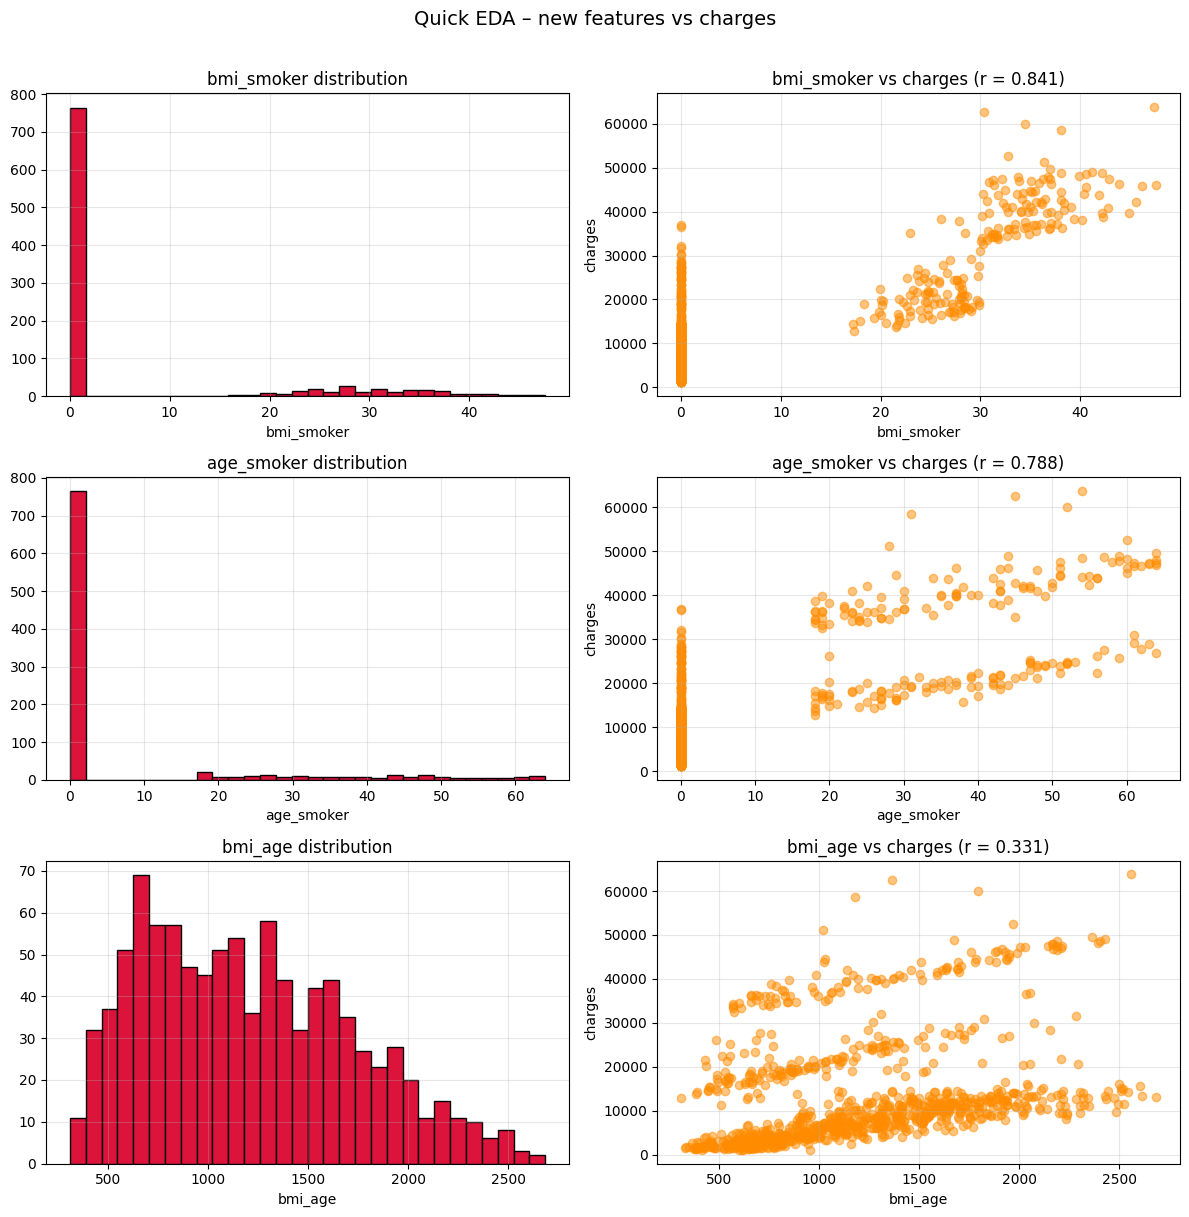

In [25]:
# Quick EDA on the numeric features
# ---------------------------------------------
def plot_features_eda(X, y, features, target_name, hist_c, scat_c, ncols=2):
    """
    For each feature in `features`, create a row with two subplots:
    histogram of the feature (left) and scatter vs target (right).
    """
    nrows = len(features)
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
    
    # Make sure axes is 2D even for a single row
    if nrows == 1:
        axes = axes.reshape(1, -1)
    
    for i, feat in enumerate(features):
        r, _ = scipy.stats.pearsonr(X[feat], y)
        
        # Histogram
        axes[i, 0].hist(X[feat], bins=30, color=hist_c, edgecolor='k')
        axes[i, 0].set_title(f'{feat} distribution')
        axes[i, 0].set_xlabel(feat)
        axes[i, 0].grid(alpha=0.3)
        
        # Scatter
        axes[i, 1].scatter(X[feat], y, alpha=0.5, color=scat_c)
        axes[i, 1].set_title(f'{feat} vs {target_name} (r = {r:.3f})')
        axes[i, 1].set_xlabel(feat)
        axes[i, 1].set_ylabel(target_name)
        axes[i, 1].grid(alpha=0.3)
    
    plt.suptitle(f'Quick EDA – new features vs {target_name}', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


plot_features_eda(x_all_train, y_train, all_new_num,
                  'charges', 'crimson', 'darkorange')



In [51]:
all_new_cat = ['obesity', 'severe_obesity', 'high_risk']

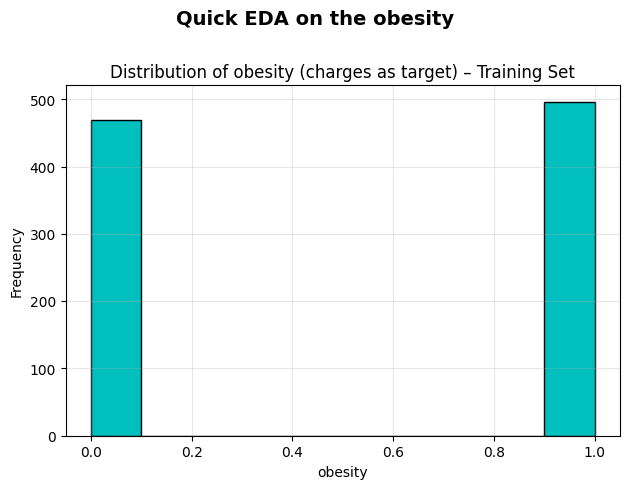

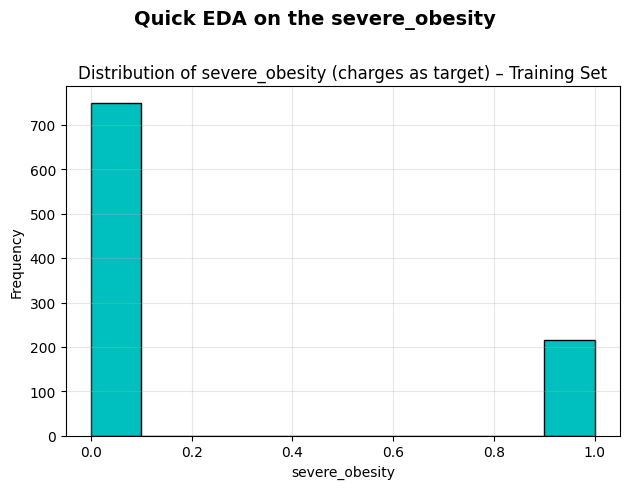

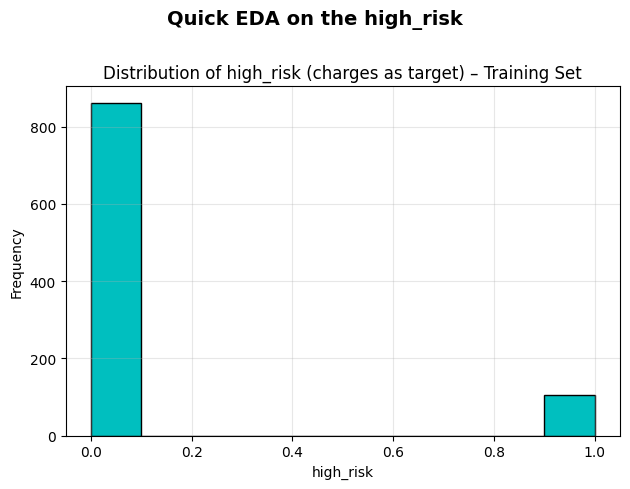

In [27]:
def plot_cat_dis(X, feat):
    # Histogram of new cat features (training set)
    X[feat].hist(color='c', edgecolor='k')
    plt.title(f'Distribution of {feat} (charges as target) – Training Set')
    plt.xlabel(feat)
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)


    plt.suptitle(f"Quick EDA on the {feat}", fontsize=14, weight='bold' ,y=1.01)
    plt.tight_layout()
    plt.show()


for f in all_new_cat:
    plot_cat_dis(x_all_train, f)

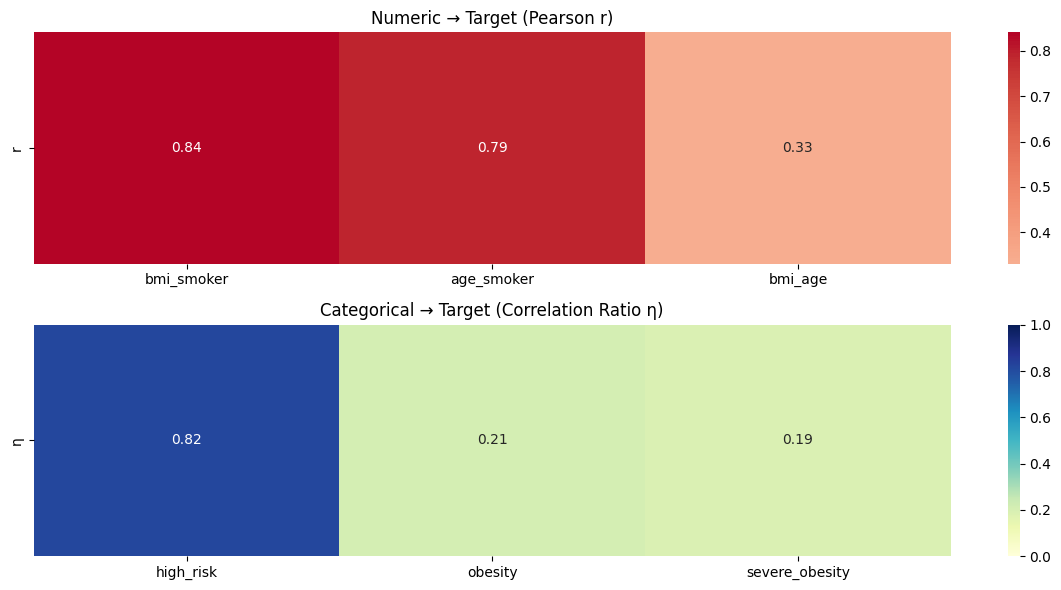

In [28]:
full_train_ana = x_all_train.copy()
full_train_ana['charges'] = y_train.values

# Now pass them to the analyzer
analyzer_all = CorrelationAnalyzer(
    data=full_train_ana,
    target_type='numeric',
    num_cols=all_new_num,
    cat_cols=all_new_cat,
    target_col='charges'
)

analyzer_all.plot_feature_numeric_target()

#### 2- Target column
- We'll apply log-transformer on the target to address it being right-skewed. 
- The difference of applying this technique is analyzed and showcased in the `EDA notebook`. 

In [52]:
# Raw targets
y_train_raw = y_train.values.astype(np.float32)
y_val_raw   = y_val.values.astype(np.float32)
y_test_raw  = y_test.values.astype(np.float32)

# Log targets
y_train_log = np.log1p(y_train_raw)
y_val_log   = np.log1p(y_val_raw)
y_test_log  = np.log1p(y_test_raw)

### 5) Core of preprocessing and handling data


In [53]:
"""
"Children was treated as a numerical count variable,
 while sex and Smoking were treated as a binary categorical variable and
 region was encoded using one-hot encoding."
"""

# =====================================================
# Feature Groups
# =====================================================

# ----- Baseline -----

baseline_num_features = ['age', 'bmi', 'children']
baseline_bin_features = ['sex', 'smoker']
baseline_nom_features = ['region']


# ----- Smoker Engineering -----

smoker_num_features = baseline_num_features + ['bmi_smoker', 'age_smoker']
smoker_bin_features = baseline_bin_features + ['high_risk']


# ----- BMI / Age Engineering -----

bmi_age_num_features = baseline_num_features + ['bmi_age']
bmi_age_bin_features = baseline_bin_features + ['obesity', 'severe_obesity']


# ----- All Engineered Features -----

all_eng_num_features = baseline_num_features + ['bmi_age', 'bmi_smoker', 'age_smoker']
all_eng_bin_features = baseline_bin_features + ['obesity', 'severe_obesity', 'high_risk']


# Pipelines
#----------------

# Continuous numeric feat
con_num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])


# Binary feat
bin_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
    )
])

# Nominal feat
nom_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])


# Combine all Pipelines to build the full preprocessors
#------------------------------------------------------

# --- Baseline ---
preprocessor_baseline = ColumnTransformer([
    ("num", con_num_pipeline, baseline_num_features),
    ("bin", bin_pipeline, baseline_bin_features),
    ("nom", nom_pipeline, baseline_nom_features)
])

# --- Smoker eng ---
preprocessor_smoker = ColumnTransformer([
    ("num", con_num_pipeline, smoker_num_features),
    ("bin", bin_pipeline, smoker_bin_features),
    ("nom", nom_pipeline, baseline_nom_features)
])

# --- BMI / Age eng ---
preprocessor_bmi_age = ColumnTransformer([
    ("num", con_num_pipeline, bmi_age_num_features),
    ("bin", bin_pipeline, bmi_age_bin_features),
    ("nom", nom_pipeline, baseline_nom_features)
])

# --- All eng ---
preprocessor_all = ColumnTransformer([
    ("num", con_num_pipeline, all_eng_num_features),
    ("bin", bin_pipeline, all_eng_bin_features),
    ("nom", nom_pipeline, baseline_nom_features)
])


print("----- Preprocessing Pipelines Ready -----")

----- Preprocessing Pipelines Ready -----


####  - Fit on the full training data and transform  

In [54]:
# Baseline
#-----------------------------

# Fit on the entire training set 
preprocessor_baseline.fit(X_train)

# Transform both training and test sets
X_train_prep_baseline = preprocessor_baseline.transform(X_train).astype(np.float32)
X_val_prep_baseline = preprocessor_baseline.transform(X_val).astype(np.float32)
X_test_prep_baseline  = preprocessor_baseline.transform(X_TEST).astype(np.float32)

print("Baseline:")
print("X_train_prep shape:", X_train_prep_baseline.shape)
print("X_val_prep shape:", X_val_prep_baseline.shape)
print("X_test_prep shape:",  X_test_prep_baseline.shape)

Baseline:
X_train_prep shape: (966, 9)
X_val_prep shape: (171, 9)
X_test_prep shape: (201, 9)


In [34]:
# Smoker
#-----------------------------

# Fit on the entire training set 
preprocessor_smoker.fit(x_smoker_train)

# Transform both training and test sets
X_train_prep_smoker = preprocessor_smoker.transform(x_smoker_train).astype(np.float32)
X_val_prep_smoker = preprocessor_smoker.transform(x_smoker_val).astype(np.float32)
X_test_prep_smoker  = preprocessor_smoker.transform(x_smoker_test).astype(np.float32)

print("Smoker Eng:")
print("X_train_prep shape:", X_train_prep_smoker.shape)
print("X_val_prep shape:", X_val_prep_smoker.shape)
print("X_test_prep shape:",  X_test_prep_smoker.shape)

Smoker Eng:
X_train_prep shape: (966, 12)
X_val_prep shape: (171, 12)
X_test_prep shape: (201, 12)


In [35]:
# BMI / Age
#-----------------------------

# Fit on the entire training set 
preprocessor_bmi_age.fit(x_bmi_age_train)

# Transform both training and test sets
X_train_prep_bmi_age = preprocessor_bmi_age.transform(x_bmi_age_train).astype(np.float32)
X_val_prep_bmi_age = preprocessor_bmi_age.transform(x_bmi_age_val).astype(np.float32)
X_test_prep_bmi_age  = preprocessor_bmi_age.transform(x_bmi_age_test).astype(np.float32)

print("BMI / Age Eng:")
print("X_train_prep shape:", X_train_prep_bmi_age.shape)
print("X_val_prep shape:", X_val_prep_bmi_age.shape)
print("X_test_prep shape:",  X_test_prep_bmi_age.shape)

BMI / Age Eng:
X_train_prep shape: (966, 12)
X_val_prep shape: (171, 12)
X_test_prep shape: (201, 12)


In [36]:
# All 
#-----------------------------

# Fit on the entire training set 
preprocessor_all.fit(x_all_train)

# Transform both training and test sets
X_train_prep_all = preprocessor_all.transform(x_all_train).astype(np.float32)
X_val_prep_all = preprocessor_all.transform(x_all_val).astype(np.float32)
X_test_prep_all  = preprocessor_all.transform(x_all_test).astype(np.float32)

print("All Eng:")
print("X_train_prep shape:", X_train_prep_all.shape)
print("X_val_prep shape:", X_val_prep_all.shape)
print("X_test_prep shape:",  X_test_prep_all.shape)

All Eng:
X_train_prep shape: (966, 15)
X_val_prep shape: (171, 15)
X_test_prep shape: (201, 15)


In [37]:
# columns check
feature_names = preprocessor_baseline.get_feature_names_out()

print(len(feature_names))
print(feature_names)

9
['num__age' 'num__bmi' 'num__children' 'bin__sex' 'bin__smoker'
 'nom__region_northeast' 'nom__region_northwest' 'nom__region_southeast'
 'nom__region_southwest']


In [38]:
# NaNs check
print(np.isnan(X_train_prep_baseline).sum())
print(np.isnan(X_train_prep_smoker).sum())
print(np.isnan(X_train_prep_bmi_age).sum())
print(np.isnan(X_train_prep_all).sum())

0
0
0
0


### 6) Architecture Benchmarking

In [142]:
#---------------------------------------------------------------------
# Build the architecture, model and fit, train, internal evaluation
#---------------------------------------------------------------------

# Main arch benchmarker
def architecture_benchmark(X, y, X_val, y_val,
                            units_n: list,
                            dout: int=0.3,
                            act_func: str='relu',
                            epochs: int=30,
                            batch_size: int=32):

    # Build Keras model with the right input shape
    input_dim = X.shape[1]
    # For fair arch comparison
    tf.keras.utils.set_random_seed(RANDOM_STATE)

    model = tf.keras.models.Sequential()

    model.add(tf.keras.layers.Input(shape=(input_dim,)))

    # Customizable addition of layers and units
    if units_n:
        for units in units_n:
            model.add(tf.keras.layers.Dense(units, activation=act_func))

    # Set dropout to prevent overfitting
    model.add(tf.keras.layers.Dropout(dout))
    # Third hidden layer with 1 unit (output layer)
    model.add(tf.keras.layers.Dense(1, activation='linear'))

    # Compile
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Stop early if validation loss doesn’t improve for 5 epochs
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Fit using numpy arrays
    history = model.fit(
        X, y,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),          
        callbacks=[early_stop],  
        verbose=0      
    )

    # Evaluate during training
    model.evaluate(X_val, y_val, verbose=2)

    return model, history


In [61]:
def evaluation(model, X_val, y_val, target_log=False):
    # Predict on validation set
    y_pred = model.predict(X_val, verbose=0).flatten()

    if target_log:
        y_pred = np.expm1(y_pred)
        y_true = np.expm1(y_val)
    else:
        y_true = y_val

    # Metrics
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)

    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")


In [57]:
def plot_training_history(history):

    fig, axes = plt.subplots(
        1, 2,
        figsize=(12,5)
    )

    # MAE
    axes[0].plot(
        history.history['mae'],
        label='Train MAE',
        linewidth=2
    )

    axes[0].plot(
        history.history['val_mae'],
        label='Validation MAE',
        linewidth=2
    )

    axes[0].set_title('MAE Plot')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MAE')
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    # Loss
    axes[1].plot(
        history.history['loss'],
        label='Train Loss',
        linewidth=2
    )

    axes[1].plot(
        history.history['val_loss'],
        label='Validation Loss',
        linewidth=2
    )

    axes[1].set_title('Loss Plot')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE')
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### - Model Selection

#### **STAGE 1:**

#### - Raw target: Architecture A

In [67]:
# Baseline
model_b, history_b = architecture_benchmark(X_train_prep_baseline,
                                        y_train_raw,
                                        X_val_prep_baseline,
                                        y_val_raw,
                                        units_n=[32, 16])

evaluation(model_b, X_val_prep_baseline, y_val_raw)
print(f"number of epochs passed: {len(history_b.history['loss'])}")

6/6 - 0s - 32ms/step - loss: 167534000.0000 - mae: 7972.6055
R²   : -0.2077
MAE  : 7972.61
RMSE : 12943.49
number of epochs passed: 30


In [68]:
# Smoker eng
model_sm, history_sm = architecture_benchmark(X_train_prep_smoker,
                                        y_train_raw,
                                        X_val_prep_smoker,
                                        y_val_raw,
                                        units_n=[32, 16])

evaluation(model_sm, X_val_prep_smoker, y_val_raw)
print(f"number of epochs passed: {len(history_sm.history['loss'])}")

6/6 - 0s - 22ms/step - loss: 145983280.0000 - mae: 7637.2690
R²   : -0.0523
MAE  : 7637.27
RMSE : 12082.35
number of epochs passed: 30


In [69]:
# BMI/Age eng
model_ba, history_ba = architecture_benchmark(X_train_prep_bmi_age,
                                        y_train_raw,
                                        X_val_prep_bmi_age,
                                        y_val_raw,
                                        units_n=[32, 16])

evaluation(model_ba, X_val_prep_bmi_age, y_val_raw)
print(f"number of epochs passed: {len(history_ba.history['loss'])}")

6/6 - 0s - 14ms/step - loss: 147042736.0000 - mae: 7377.3188
R²   : -0.0600
MAE  : 7377.32
RMSE : 12126.12
number of epochs passed: 30


In [70]:
# all eng
model_all, history_all = architecture_benchmark(X_train_prep_all,
                                        y_train_raw,
                                        X_val_prep_all,
                                        y_val_raw,
                                        units_n=[32, 16])

evaluation(model_all, X_val_prep_all, y_val_raw)
print(f"number of epochs passed: {len(history_all.history['loss'])}")

6/6 - 0s - 18ms/step - loss: 126083440.0000 - mae: 6988.5767
R²   : 0.0911
MAE  : 6988.58
RMSE : 11228.69
number of epochs passed: 30


#### - Log target: Architecture A

In [71]:
# baseline
model_b_log, history_b_log = architecture_benchmark(X_train_prep_baseline,
                                        y_train_log,
                                        X_val_prep_baseline,
                                        y_val_log,
                                        units_n=[32, 16])

evaluation(model_b_log, X_val_prep_baseline, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_b_log.history['loss'])}")

6/6 - 0s - 16ms/step - loss: 0.2773 - mae: 0.3694
R²   : 0.5529
MAE  : 4359.30
RMSE : 7875.25
number of epochs passed: 22


In [72]:
# smoker eng
model_sm_log, history_sm_log = architecture_benchmark(X_train_prep_smoker,
                                        y_train_log,
                                        X_val_prep_smoker,
                                        y_val_log,
                                        units_n=[32, 16])

evaluation(model_sm_log, X_val_prep_smoker, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_sm_log.history['loss'])}")

6/6 - 0s - 23ms/step - loss: 0.2176 - mae: 0.3132
R²   : 0.6046
MAE  : 3788.37
RMSE : 7406.27
number of epochs passed: 30


In [73]:
# bmi/age eng
model_ba_log, history_ba_log = architecture_benchmark(X_train_prep_bmi_age,
                                        y_train_log,
                                        X_val_prep_bmi_age,
                                        y_val_log,
                                        units_n=[32, 16])

evaluation(model_ba_log, X_val_prep_bmi_age, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_ba_log.history['loss'])}")

6/6 - 0s - 24ms/step - loss: 0.2802 - mae: 0.3828
R²   : 0.4481
MAE  : 4829.83
RMSE : 8749.73
number of epochs passed: 22


In [74]:
# all eng
model_all_log, history_all_log = architecture_benchmark(X_train_prep_all,
                                        y_train_log,
                                        X_val_prep_all,
                                        y_val_log,
                                        units_n=[32, 16])

evaluation(model_all_log, X_val_prep_all, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_all_log.history['loss'])}")

6/6 - 0s - 19ms/step - loss: 0.2765 - mae: 0.3904
R²   : 0.5829
MAE  : 4361.39
RMSE : 7606.51
number of epochs passed: 22


### Stage 1 – Dataset and Target Selection

A baseline ANN architecture consisting of two hidden layers (32 and 16 neurons) was evaluated across the four feature-engineering scenarios and two target representations (raw charges and log-transformed charges).

The results revealed a substantial improvement when the logarithmic target transformation was used. While models trained on the raw target produced poor predictive performance and frequently yielded negative R² values, the log-transformed target consistently achieved stronger generalization performance across all feature-engineering scenarios.

Among the evaluated datasets, the smoker-engineered feature set produced the highest validation performance, achieving an R² score of approximately 0.60. This finding is consistent with the earlier machine-learning experiments, where smoking-related interaction features also provided the strongest predictive signal.

Based on these results, the remaining architecture-search experiments will be conducted using the smoker-engineered, bmi/age-engineerd and all engineered datasets together with the log-transformed target variable.


#### **STAGE 2:**

In [77]:
# Architecture A1
arch_a1 = [64, 32]
# Architecture A2
arch_a2 = [128, 64]
# Architecture A3
arch_a3 = [128, 64, 32]
# Architecture A4
arch_a4 = [128, 64, 32, 16]

#### - Log target: Architecture A1 / Baseline dataset excluded

In [76]:
# smoker eng
model_sm_log_a1, history_sm_log_a1 = architecture_benchmark(X_train_prep_smoker,
                                        y_train_log,
                                        X_val_prep_smoker,
                                        y_val_log,
                                        units_n=arch_a1)

evaluation(model_sm_log_a1, X_val_prep_smoker, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_sm_log_a1.history['loss'])}")

6/6 - 0s - 17ms/step - loss: 0.1903 - mae: 0.2786
R²   : 0.6361
MAE  : 3627.81
RMSE : 7105.10
number of epochs passed: 30


In [79]:
# bmi/age eng
model_ba_log_a1, history_ba_log_a1 = architecture_benchmark(X_train_prep_bmi_age,
                                        y_train_log,
                                        X_val_prep_bmi_age,
                                        y_val_log,
                                        units_n=arch_a1)

evaluation(model_ba_log_a1, X_val_prep_bmi_age, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_ba_log_a1.history['loss'])}")

6/6 - 0s - 15ms/step - loss: 0.2137 - mae: 0.3176
R²   : 0.5815
MAE  : 4056.09
RMSE : 7619.67
number of epochs passed: 30


In [83]:
# all eng
model_all_log_a1, history_all_log_a1 = architecture_benchmark(X_train_prep_all,
                                        y_train_log,
                                        X_val_prep_all,
                                        y_val_log,
                                        units_n=arch_a1)

evaluation(model_all_log_a1, X_val_prep_all, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_all_log_a1.history['loss'])}")

6/6 - 0s - 14ms/step - loss: 0.1849 - mae: 0.2742
R²   : 0.7092
MAE  : 3351.39
RMSE : 6351.83
number of epochs passed: 30


#### - Log target: Architecture A2 / Baseline dataset excluded

In [80]:
# smoker eng
model_sm_log_a2, history_sm_log_a2 = architecture_benchmark(X_train_prep_smoker,
                                        y_train_log,
                                        X_val_prep_smoker,
                                        y_val_log,
                                        units_n=arch_a2)

evaluation(model_sm_log_a2, X_val_prep_smoker, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_sm_log_a2.history['loss'])}")

6/6 - 0s - 14ms/step - loss: 0.1354 - mae: 0.2174
R²   : 0.8102
MAE  : 2767.51
RMSE : 5131.74
number of epochs passed: 30


In [81]:
# bmi/age eng
model_ba_log_a2, history_ba_log_a2 = architecture_benchmark(X_train_prep_bmi_age,
                                        y_train_log,
                                        X_val_prep_bmi_age,
                                        y_val_log,
                                        units_n=arch_a2)

evaluation(model_ba_log_a2, X_val_prep_bmi_age, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_ba_log_a2.history['loss'])}")

6/6 - 0s - 21ms/step - loss: 0.1998 - mae: 0.3120
R²   : 0.5816
MAE  : 4100.27
RMSE : 7618.58
number of epochs passed: 14


In [84]:
# all eng
model_all_log_a2, history_all_log_a2 = architecture_benchmark(X_train_prep_all,
                                        y_train_log,
                                        X_val_prep_all,
                                        y_val_log,
                                        units_n=arch_a2)

evaluation(model_all_log_a2, X_val_prep_all, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_all_log_a2.history['loss'])}")

6/6 - 0s - 13ms/step - loss: 0.1916 - mae: 0.2886
R²   : 0.7591
MAE  : 3191.89
RMSE : 5781.07
number of epochs passed: 22


#### - Log target: Architecture A3 / Baseline dataset excluded

In [85]:
# smoker eng
model_sm_log_a3, history_sm_log_a3 = architecture_benchmark(X_train_prep_smoker,
                                        y_train_log,
                                        X_val_prep_smoker,
                                        y_val_log,
                                        units_n=arch_a3)

evaluation(model_sm_log_a3, X_val_prep_smoker, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_sm_log_a3.history['loss'])}")

6/6 - 0s - 24ms/step - loss: 0.1782 - mae: 0.2704
R²   : 0.7526
MAE  : 3158.61
RMSE : 5857.97
number of epochs passed: 20


In [86]:
# bmi/age eng
model_ba_log_a3, history_ba_log_a3 = architecture_benchmark(X_train_prep_bmi_age,
                                        y_train_log,
                                        X_val_prep_bmi_age,
                                        y_val_log,
                                        units_n=arch_a3)

evaluation(model_ba_log_a3, X_val_prep_bmi_age, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_ba_log_a3.history['loss'])}")

6/6 - 0s - 13ms/step - loss: 0.2085 - mae: 0.3090
R²   : 0.5610
MAE  : 3985.33
RMSE : 7803.49
number of epochs passed: 20


In [87]:
# all eng
model_all_log_a3, history_all_log_a3 = architecture_benchmark(X_train_prep_all,
                                        y_train_log,
                                        X_val_prep_all,
                                        y_val_log,
                                        units_n=arch_a3)

evaluation(model_all_log_a3, X_val_prep_all, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_all_log_a3.history['loss'])}")

6/6 - 0s - 14ms/step - loss: 0.1988 - mae: 0.2980
R²   : 0.7139
MAE  : 3326.94
RMSE : 6300.33
number of epochs passed: 20


#### - Log target: Architecture A4 /  Baseline dataset excluded

In [88]:
# smoker eng
model_sm_log_a4, history_sm_log_a4 = architecture_benchmark(X_train_prep_smoker,
                                        y_train_log,
                                        X_val_prep_smoker,
                                        y_val_log,
                                        units_n=arch_a4)

evaluation(model_sm_log_a4, X_val_prep_smoker, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_sm_log_a4.history['loss'])}")

6/6 - 0s - 13ms/step - loss: 0.2430 - mae: 0.3434
R²   : 0.6591
MAE  : 3968.25
RMSE : 6877.21
number of epochs passed: 20


In [89]:
# bmi/age eng
model_ba_log_a4, history_ba_log_a4 = architecture_benchmark(X_train_prep_bmi_age,
                                        y_train_log,
                                        X_val_prep_bmi_age,
                                        y_val_log,
                                        units_n=arch_a4)

evaluation(model_ba_log_a4, X_val_prep_bmi_age, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_ba_log_a4.history['loss'])}")

6/6 - 0s - 12ms/step - loss: 0.2470 - mae: 0.3637
R²   : 0.4740
MAE  : 4551.92
RMSE : 8542.08
number of epochs passed: 13


In [90]:
# all eng
model_all_log_a4, history_all_log_a4 = architecture_benchmark(X_train_prep_all,
                                        y_train_log,
                                        X_val_prep_all,
                                        y_val_log,
                                        units_n=arch_a4)

evaluation(model_all_log_a4, X_val_prep_all, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_all_log_a4.history['loss'])}")

6/6 - 0s - 12ms/step - loss: 0.2424 - mae: 0.3618
R²   : 0.4671
MAE  : 4522.23
RMSE : 8597.83
number of epochs passed: 13


### Stage 2 – Architecture Comparison

After identifying the logarithmically transformed target as the preferred learning objective, a second series of experiments was conducted to investigate the effect of neural-network architecture on predictive performance.

Four feed-forward architectures with increasing depth and capacity were evaluated on the three engineered datasets:

* Smoker-related engineered features
* BMI/Age-related engineered features
* All engineered features combined

The results demonstrated that architecture design had a substantial impact on model performance.

The best overall performance was achieved by:

* Dataset: **Smoker Feature Engineering**
* Target: **Log(Charges)**
* Architecture: **128 → 64**
* Validation R²: **0.810**
* Validation MAE: **2768**
* Validation RMSE: **5132**

Increasing network depth beyond this configuration did not improve performance. In fact, deeper architectures (A3 and A4) generally produced lower validation scores and triggered earlier stopping, suggesting reduced generalization and potential overfitting.

These findings indicate that moderate model complexity is sufficient for this dataset and that smoker-related engineered features continue to provide the strongest predictive signal.

Based on these results, the Smoker-engineered dataset combined with the 128→64 architecture was selected for final model development and held-out test evaluation.

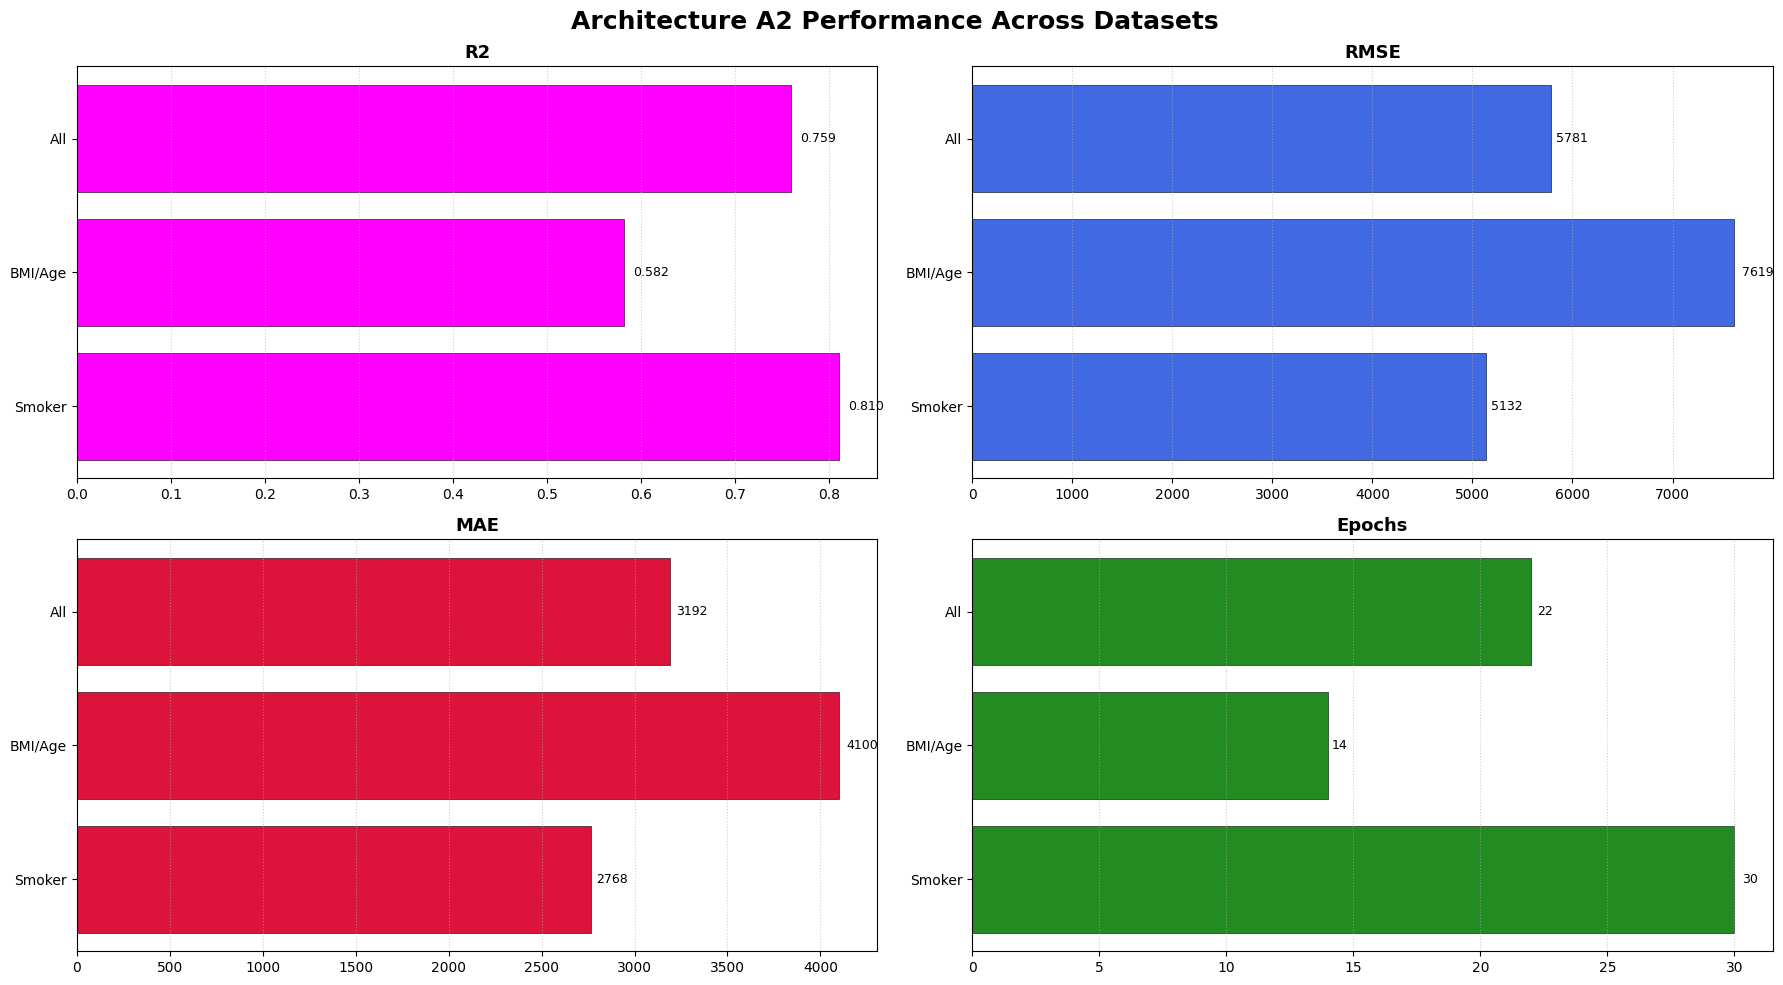

In [ ]:
# Stage 2 results saved into miscellaneous.py
from miscellaneous import stage2_results as st2r

st2r_df = pd.DataFrame(st2r['A2'])

fig, axs = plt.subplots(2, 2, figsize=(18, 10))

metrics = ['R2', 'RMSE', 'MAE', 'Epochs']
colors = ['magenta', 'royalblue', 'crimson', 'forestgreen']

for ax, metric, color in zip(axs.flatten(), metrics, colors):

    bars = ax.barh(
        st2r_df.columns,
        st2r_df.loc[metric],
        color=color,
        edgecolor='black',
        linewidth=0.4
    )

    ax.set_title(metric, fontsize=13, weight='bold')
    ax.grid(axis='x', linestyle=':', alpha=0.6)

    for bar in bars:
        value = bar.get_width()

        ax.text(
            value + (0.01 if metric == 'R2' else value * 0.01),
            bar.get_y() + bar.get_height()/2,
            f'{value:.3f}' if metric == 'R2' else f'{value:.0f}',
            va='center',
            fontsize=9
        )

plt.suptitle(
    "Architecture A2 Performance Across Datasets",
    fontsize=18,
    weight='bold'
)

plt.tight_layout()
plt.show()

#### **STAGE 3:**

#### - Perform a few small refinements around the best model

In [ ]:
# smoker eng
model_smoker_hyp_tun1, history_smoker_hyp_tun1 = architecture_benchmark(X_train_prep_smoker,
                                        y_train_log,
                                        X_val_prep_smoker,
                                        y_val_log,
                                        units_n=arch_a2,
                                        dout=0.1,
                                        epochs=40)

evaluation(model_smoker_hyp_tun1, X_val_prep_smoker, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_smoker_hyp_tun1.history['loss'])}")

6/6 - 0s - 13ms/step - loss: 0.1290 - mae: 0.1900
R²   : 0.8626
MAE  : 2150.18
RMSE : 4365.45
number of epochs passed: 29


In [ ]:
# smoker eng
model_smoker_hyp_tun2, history_smoker_hyp_tun2 = architecture_benchmark(X_train_prep_smoker,
                                        y_train_log,
                                        X_val_prep_smoker,
                                        y_val_log,
                                        units_n=arch_a2,
                                        dout=0.1,
                                        epochs=40,
                                        batch_size=48)

evaluation(model_smoker_hyp_tun2, X_val_prep_smoker, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_smoker_hyp_tun2.history['loss'])}")

6/6 - 0s - 14ms/step - loss: 0.1247 - mae: 0.2003
R²   : 0.8518
MAE  : 2346.82
RMSE : 4533.79
number of epochs passed: 35


In [156]:
# smoker eng
model_smoker_hyp_tun3, history_smoker_hyp_tun3 = architecture_benchmark(X_train_prep_smoker,
                                        y_train_log,
                                        X_val_prep_smoker,
                                        y_val_log,
                                        units_n=arch_a2,
                                        dout=0.05,
                                        epochs=40,
                                        batch_size=48)

evaluation(model_smoker_hyp_tun3, X_val_prep_smoker, y_val_log, target_log=True)
print(f"number of epochs passed: {len(history_smoker_hyp_tun3.history['loss'])}")

6/6 - 0s - 14ms/step - loss: 0.1269 - mae: 0.1842
R²   : 0.8551
MAE  : 2181.30
RMSE : 4483.12
number of epochs passed: 32


#### - The results of benchmarking visualized

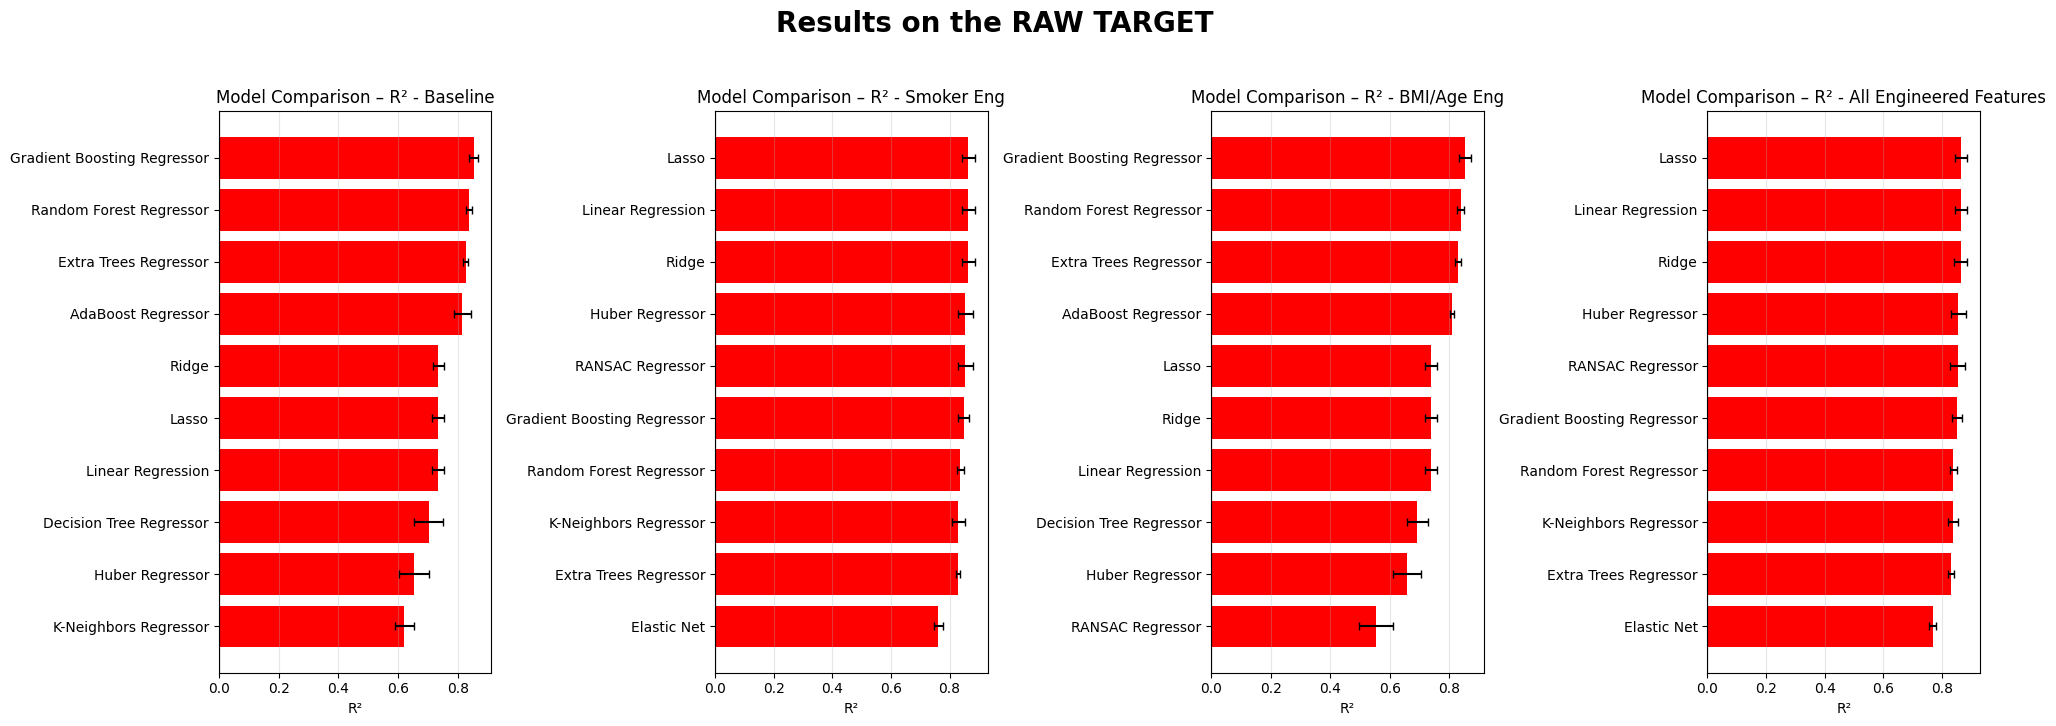

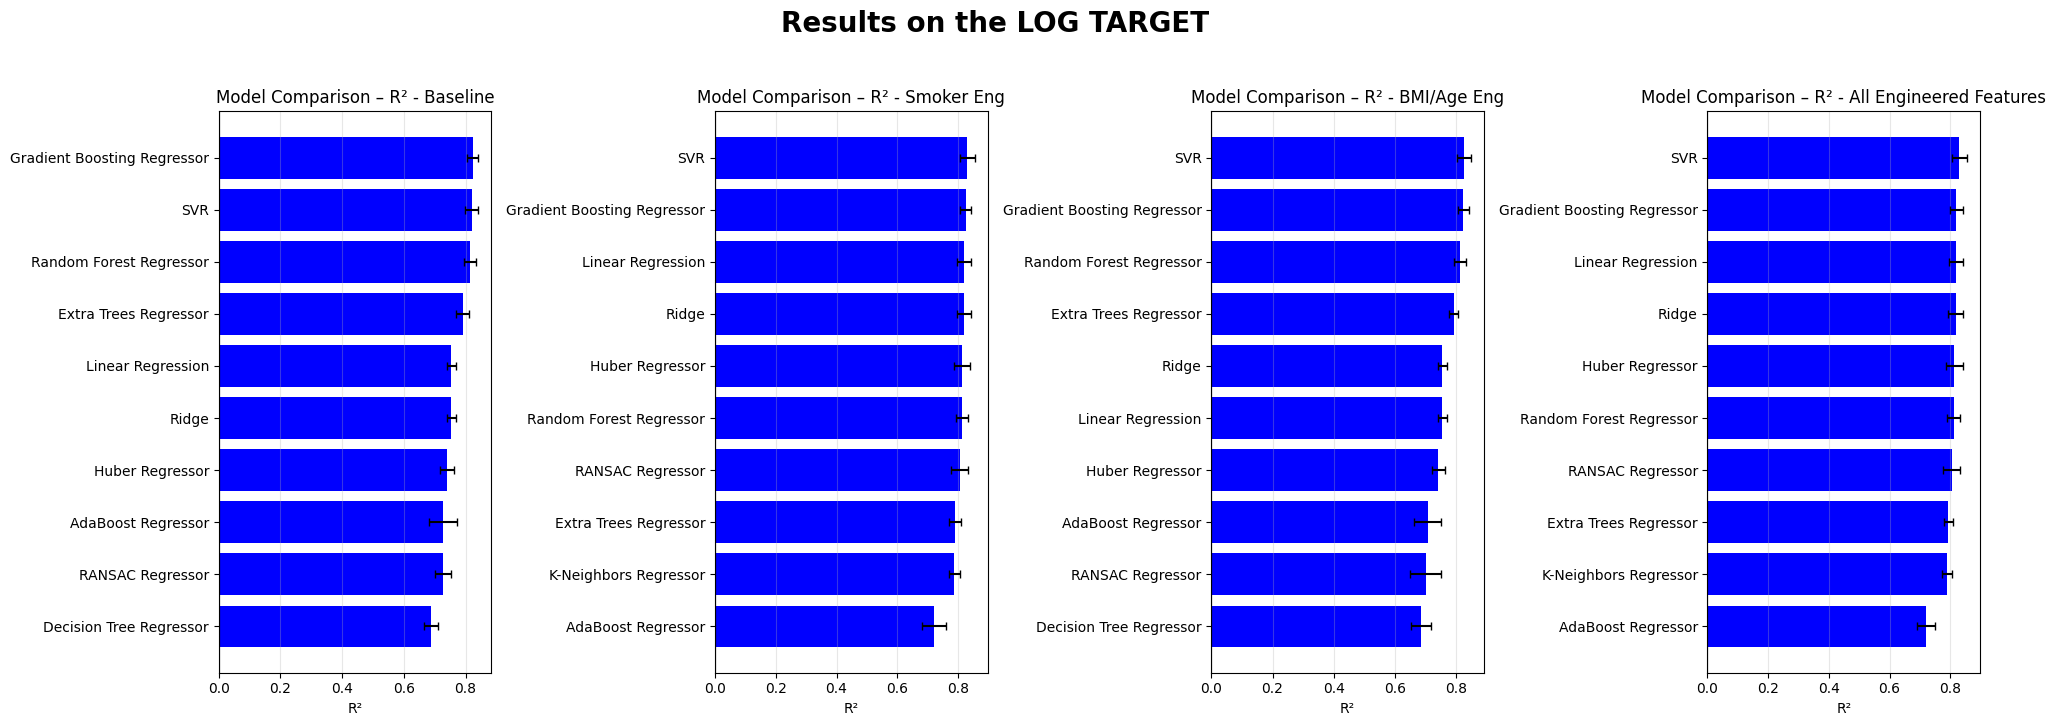

In [105]:
def plot_benchmarking_results(dfs: list, m: str, fe_sets: list, color):

    fig, axs = plt.subplots(1, 4, figsize=(20, 7))

    for i, (df, fe_set) in enumerate(zip(dfs, fe_sets)):
        # Top 10
        df = df.head(10)
        # --- R² ---
        axs[i].barh(df['Model'], df['R2_mean'],
                xerr=df['R2_std'], color=color, capsize=3)
        axs[i].axvline(0, color='black', linewidth=0.8)
        axs[i].set_xlabel('R²')
        axs[i].set_title(f'Model Comparison – R² - {fe_set}')
        axs[i].invert_yaxis()
        axs[i].grid(axis='x', alpha=0.3)

    plt.suptitle(f"Results on the {m}", fontsize=20, y=1.03, weight='bold')

    plt.tight_layout()
    plt.show()


raw_results = [baseline_results_raw, smoker_results_raw, bmi_age_results_raw, all_eng_results_raw]
log_results = [baseline_results_log, smoker_results_log, bmi_age_results_log, all_eng_results_log]

fe_sets = ['Baseline', 'Smoker Eng', 'BMI/Age Eng', 'All Engineered Features']

plot_benchmarking_results(dfs=raw_results, m='RAW TARGET', fe_sets=fe_sets, color='r')
plot_benchmarking_results(dfs=log_results, m='LOG TARGET', fe_sets=fe_sets, color='b')


#### -  Predicted‑vs‑actual scatter for top‑3 regressors

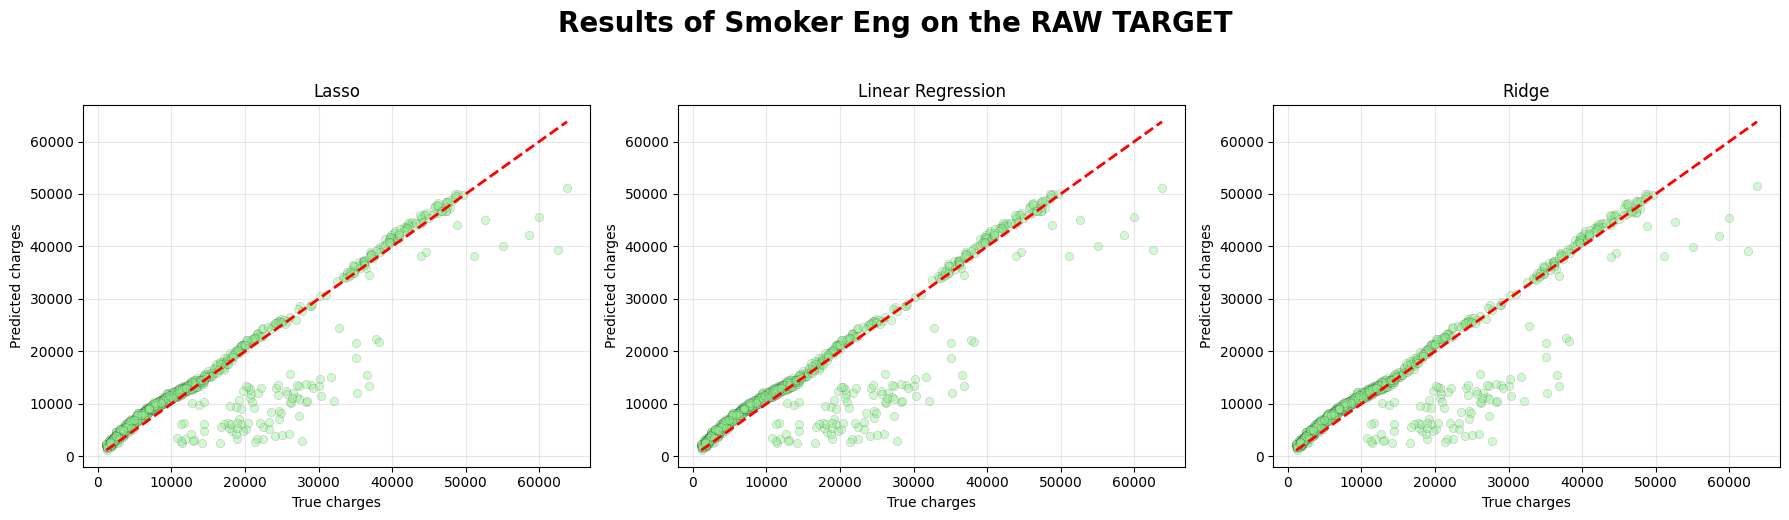

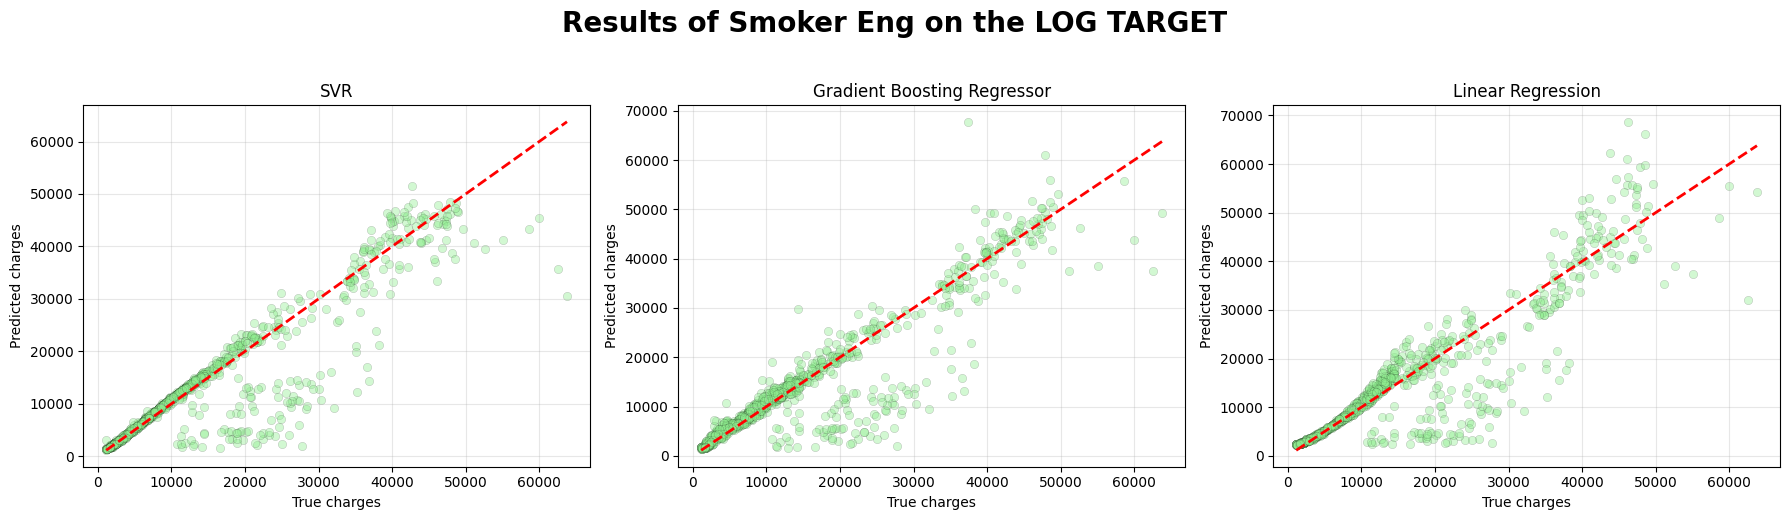

In [107]:
def plot_pred_vs_act(df, X, y, text, log_target=False):
    # Choose top 3 models by R2_mean (from results_df)
    top3_names = df['Model'].head(3).tolist()
    top3_models = {name: models[name] for name in top3_names}

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (name, model) in zip(axes, top3_models.items()):
        reg = clone(model)
        y_cv_pred = cross_val_predict(reg, X, y,
                                    cv=5, n_jobs=-1)
        if log_target:
            y_plot = np.expm1(y)
            y_cv_pred = np.expm1(y_cv_pred)
        else:
            y_plot = y

        ax.scatter(
            y_plot,
            y_cv_pred,
            alpha=0.4,
            edgecolors='k',
            color='lightgreen',
            linewidth=0.2
        )

        ax.plot(
            [y_plot.min(), y_plot.max()],
            [y_plot.min(), y_plot.max()],
            'r--',
            lw=2
        )
        ax.set_xlabel('True charges')
        ax.set_ylabel('Predicted charges')
        ax.set_title(name)
        ax.grid(alpha=0.3)

    plt.suptitle(f"Results of {text}", fontsize=20, y=1.03, weight='bold')

    plt.tight_layout()
    plt.show()


plot_pred_vs_act(smoker_results_raw, X_train_prep_smoker, y_train_raw, 'Smoker Eng on the RAW TARGET')
plot_pred_vs_act(smoker_results_log, X_train_prep_smoker, y_train_log, 'Smoker Eng on the LOG TARGET', log_target=True)


### 7) The final training on the full train set 


In [108]:

lasso_final = Lasso(random_state=RANDOM_STATE)

lasso_final.fit(
    X_train_prep_smoker,
    y_train_raw
)


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [109]:

ridge_final = Ridge(random_state=RANDOM_STATE)

ridge_final.fit(
    X_train_prep_smoker,
    y_train_raw
)


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",42


In [110]:

linear_final = LinearRegression()

linear_final.fit(
    X_train_prep_smoker,
    y_train_raw
)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 8) The final evaluation on the test set (For three trained models)

#### - Fundamental evaluation metrics

In [112]:
# Predict on the test set
y_pred_lasso = lasso_final.predict(
    X_test_prep_smoker
)

# Compute evaluation metrics (RMSE - MAE - R²)
r2_lasso = r2_score(y_test_raw, y_pred_lasso)
rmse_lasso = root_mean_squared_error(y_test_raw, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test_raw, y_pred_lasso)

print(f"Test set performance (Lasso):")
print(f"R²   : {r2_lasso:.4f}")
print(f"RMSE : {rmse_lasso:.2f}")
print(f"MAE  : {mae_lasso:.2f}")

Test set performance (Lasso):
R²   : 0.8821
RMSE : 4237.68
MAE  : 2304.42


In [114]:
# Predict on the test set
y_pred_ridge = ridge_final.predict(
    X_test_prep_smoker
)

# Compute evaluation metrics (RMSE - MAE - R²)
r2_ridge = r2_score(y_test_raw, y_pred_ridge)
rmse_ridge = root_mean_squared_error(y_test_raw, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test_raw, y_pred_ridge)

print(f"Test set performance (ridge):")
print(f"R²   : {r2_ridge:.4f}")
print(f"RMSE : {rmse_ridge:.2f}")
print(f"MAE  : {mae_ridge:.2f}")

Test set performance (ridge):
R²   : 0.8825
RMSE : 4230.34
MAE  : 2298.73


In [115]:
# Predict on the test set
y_pred_linear = linear_final.predict(
    X_test_prep_smoker
)

# Compute evaluation metrics (RMSE - MAE - R²)
r2_linear = r2_score(y_test_raw, y_pred_linear)
rmse_linear = root_mean_squared_error(y_test_raw, y_pred_linear)
mae_linear = mean_absolute_error(y_test_raw, y_pred_linear)

print(f"Test set performance (linear):")
print(f"R²   : {r2_linear:.4f}")
print(f"RMSE : {rmse_linear:.2f}")
print(f"MAE  : {mae_linear:.2f}")

Test set performance (linear):
R²   : 0.8821
RMSE : 4237.22
MAE  : 2304.80


### 9) More visualization on the final model (Ridge Regression)

#### -  Plot predicted vs actual (test set)

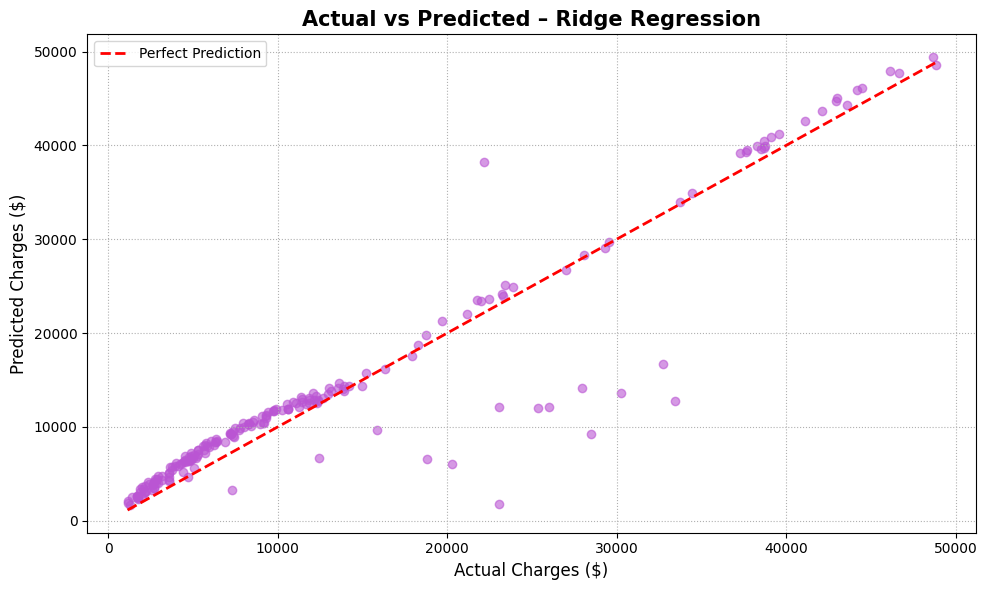

In [147]:
plt.figure(figsize=(10,6))

plt.scatter(
    y_test_raw,
    y_pred_ridge,
    alpha=0.6,
    color='mediumorchid'
)
plt.plot(
    [y_test_raw.min(), y_test_raw.max()],
    [y_test_raw.min(), y_test_raw.max()],
    'r--',
    lw=2,
    label='Perfect Prediction'
)
plt.xlabel('Actual Charges ($)', fontsize=12)
plt.ylabel('Predicted Charges ($)', fontsize=12)
plt.title('Actual vs Predicted – Ridge Regression', fontsize=15, weight='bold')
plt.legend()
plt.grid(True, linestyle=':')

plt.tight_layout()
plt.show()

#### - Residual plot

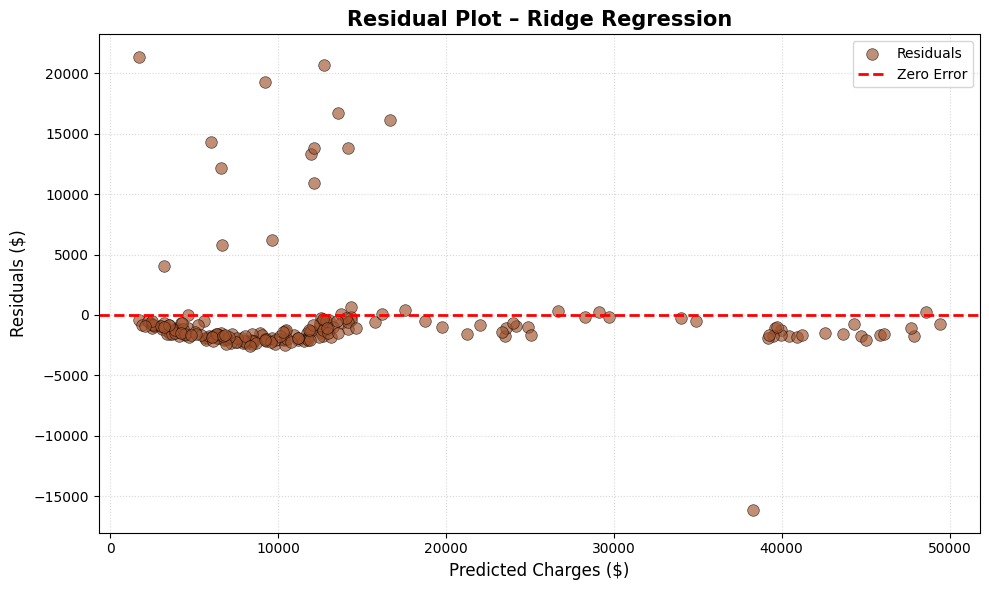

In [149]:
residuals = y_test_raw - y_pred_ridge

plt.figure(figsize=(10,6))

plt.scatter(
    y_pred_ridge,
    residuals,
    alpha=0.65,
    s=70,
    edgecolor='black',
    linewidth=0.5,
    color='sienna',
    label='Residuals'
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Zero Error'
)

plt.xlabel('Predicted Charges ($)', fontsize=12)
plt.ylabel('Residuals ($)', fontsize=12)
plt.title('Residual Plot – Ridge Regression', fontsize=15, weight='bold')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

#### - Coefficient (Feature) importance

In [164]:
feature_names = preprocessor_smoker.get_feature_names_out()

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': ridge_final.coef_
})

coef_df['AbsCoef'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('AbsCoef', ascending=True)

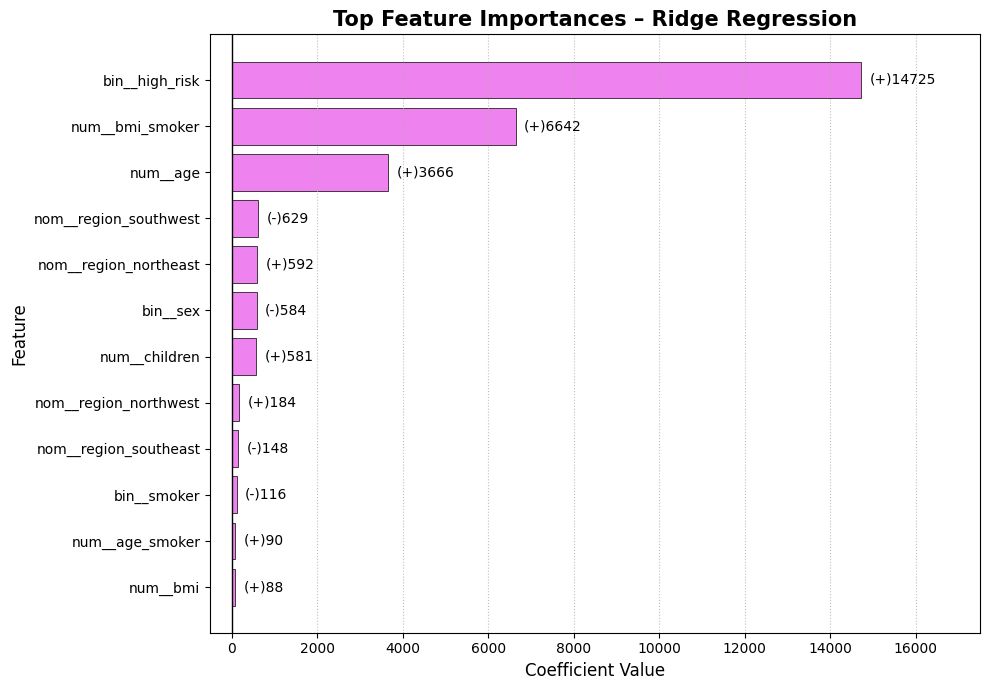

In [165]:
top_n = 12
plot_df = (coef_df.head(top_n))

plt.figure(figsize=(10,7))

bars = plt.barh(
    plot_df['Feature'],
    plot_df['AbsCoef'],
    color='violet',
    edgecolor='black',
    linewidth=0.5
)

plt.axvline(
    x=0,
    color='black',
    linewidth=1
)

plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top Feature Importances – Ridge Regression', fontsize=15, weight='bold')
plt.grid(axis='x', linestyle=':', alpha=0.8)
plt.xlim(-500, 17500)

for i, v in enumerate(plot_df['Coefficient']):

    if v >= 0:
        plt.text(
            v + 200,
            i,
            f'(+){v:.0f}',
            va='center',
            fontsize=10
        )

    else:
        plt.text(
            abs(v) + 200,
            i,
            f'(-){abs(v):.0f}',
            va='center',
            fontsize=10
        )

plt.tight_layout()
plt.show()

In [166]:
#--------------------------------------------
# Save the model & preprocessing pipeline
#--------------------------------------------

joblib.dump(ridge_final, PROJECT_ROOT / "Models/Regression/ml_insurance_cost_model.joblib")
print("Model Saved: ml_insurance_cost_model.joblib")

Model Saved: ml_insurance_cost_model.joblib


## Conclusion – Medical Insurance Cost Regression

In this regression study, the objective was to predict **individual medical insurance charges** using demographic and health-related attributes from the Medical Cost Personal Dataset. The workflow followed a complete machine-learning pipeline including exploratory data analysis, preprocessing, feature engineering, cross-validation benchmarking, model selection, and final evaluation on an independent test set.

* **Baseline modeling performance** – A broad collection of regression algorithms was evaluated, including linear models, robust regressors, support vector regression, tree-based methods, and ensemble learners. Initial benchmarking demonstrated that both linear and ensemble approaches were capable of explaining a large proportion of the variance in insurance charges, indicating the presence of strong predictive relationships within the dataset.

* **Feature engineering experiments** – Multiple domain-inspired feature engineering strategies were investigated:

  * Smoking-related interaction features:

    * BMI × Smoker
    * Age × Smoker
    * High-Risk Indicator (Obesity × Smoker)

  * BMI and Age interaction features:

    * BMI × Age
    * Obesity Indicator
    * Severe Obesity Indicator

  * Combined feature-engineering scenario incorporating all engineered variables.

  Correlation analysis revealed that the smoking-related interaction variables exhibited the strongest relationship with insurance charges, particularly the BMI-Smoker interaction and High-Risk indicator. These engineered variables substantially improved model performance compared with the baseline feature set.

* **Target transformation experiments** – Both the original insurance charges and a logarithmically transformed target variable were evaluated. Although the log-transformed target produced improvements for several linear models during cross-validation, the highest overall predictive performance was obtained using the original target values, preserving direct interpretability of predictions in monetary units.

* **Model comparison and selection** – Systematic benchmarking across all feature-engineering scenarios showed that the strongest cross-validated performance was achieved using:

  * **Smoking-related engineered features**
  * **Original (raw) target variable**
  * **Lasso Regression**

  with a cross-validated performance of:

  * **R² ≈ 0.864**

  The results demonstrate that carefully designed domain-specific features can provide greater benefits than increasing model complexity alone.

* **Final test-set evaluation** – The three strongest linear models identified during benchmarking (Lasso, Ridge, and Linear Regression) were subsequently evaluated on the independent test set. Among them, **Ridge Regression** achieved the best overall performance:

  * **R² = 0.8825**
  * **RMSE = 4230**
  * **MAE = 2299**

  The similarity between cross-validation and test-set performance indicates strong generalization capability and minimal evidence of overfitting.

* **Model interpretation** – Feature importance analysis using Ridge coefficients confirmed that smoking-related variables dominated the prediction process. In particular:

  * High-Risk (Obesity × Smoker)
  * BMI × Smoker
  * Age

  emerged as the most influential predictors of insurance costs. These findings are consistent with established clinical and public-health knowledge regarding the economic impact of smoking and obesity on healthcare expenditure.

### Key Take-away

This study demonstrates how combining domain knowledge with systematic machine-learning methodology can substantially improve predictive performance.

The framework successfully:

* Produced reproducible and unbiased model evaluations through cross-validation.
* Demonstrated the effectiveness of clinically motivated feature engineering.
* Identified smoking-related interactions as the strongest drivers of insurance costs.
* Achieved strong predictive accuracy on unseen data.
* Balanced predictive performance with interpretability through the selection of a linear final model.

Overall, the results show that insurance charges can be predicted with high accuracy using a relatively small number of demographic and health-related variables when appropriate feature engineering techniques are applied. The workflow provides a practical and interpretable framework that can be extended to other healthcare cost prediction problems and medical tabular datasets.
